# Theta*: A Self-Learning Demo

## Why Theta*?

Theta* is an any-angle variant of A*.
It tries to keep the efficiency of grid search while producing straighter and less jagged paths.

In this notebook, you will:

1. Build an occupancy grid.
2. Implement A* and Theta* on the same map.
3. Compare the shape and length of the resulting paths.
4. Explore map changes interactively.

## Theta* Method Essentials

Keep these ideas in mind while reading the code:

- **A* base structure**: Theta* still uses a priority queue and graph search logic.
- **Line of sight**: the key extra step checks whether two cells can connect directly.
- **Parent shortcutting**: if the parent of the current node can see a neighbor, Theta* may skip the current node entirely.
- **Any-angle path**: the result is often smoother than standard A*.

## 1) Helper Functions

The first code cell defines both A* and Theta* so you can compare them under the same conditions.

Pay special attention to `line_of_sight` and the parent update inside `theta_star_grid`.

In [ ]:
%matplotlib inline
from heapq import heappop, heappush
from math import hypot
from typing import Dict, List, Optional, Tuple

import ipywidgets as widgets
import matplotlib.pyplot as plt
import numpy as np
from IPython.display import display

Point = Tuple[int, int]


def neighbors8(cell: Point, shape: Tuple[int, int]) -> List[Point]:
    r, c = cell
    rows, cols = shape
    out: List[Point] = []
    for dr in (-1, 0, 1):
        for dc in (-1, 0, 1):
            if dr == 0 and dc == 0:
                continue
            nr, nc = r + dr, c + dc
            if 0 <= nr < rows and 0 <= nc < cols:
                out.append((nr, nc))
    return out


def euclidean(a: Point, b: Point) -> float:
    return float(hypot(a[0] - b[0], a[1] - b[1]))


def bresenham_cells(a: Point, b: Point) -> List[Point]:
    r0, c0 = a
    r1, c1 = b
    dr = abs(r1 - r0)
    dc = abs(c1 - c0)
    sr = 1 if r0 < r1 else -1
    sc = 1 if c0 < c1 else -1
    err = dr - dc

    cells: List[Point] = []
    while True:
        cells.append((r0, c0))
        if r0 == r1 and c0 == c1:
            break
        e2 = 2 * err
        if e2 > -dc:
            err -= dc
            r0 += sr
        if e2 < dr:
            err += dr
            c0 += sc
    return cells


def line_of_sight(grid: np.ndarray, a: Point, b: Point) -> bool:
    cells = bresenham_cells(a, b)

    # Every traversed cell must be free.
    for rr, cc in cells:
        if grid[rr, cc] == 1:
            return False

    # For diagonal transitions, block corner-cutting through touching obstacles.
    for (r0, c0), (r1, c1) in zip(cells[:-1], cells[1:]):
        dr = r1 - r0
        dc = c1 - c0
        if abs(dr) == 1 and abs(dc) == 1:
            if grid[r0, c1] == 1 and grid[r1, c0] == 1:
                return False
    return True


def reconstruct(parent: Dict[Point, Optional[Point]], goal: Point) -> Optional[List[Point]]:
    if goal not in parent:
        return None
    path: List[Point] = []
    cur: Optional[Point] = goal
    while cur is not None:
        path.append(cur)
        cur = parent[cur]
    path.reverse()
    return path


def a_star_grid(grid: np.ndarray, start: Point, goal: Point) -> Optional[List[Point]]:
    if grid[start] == 1 or grid[goal] == 1:
        return None
    g_score: Dict[Point, float] = {start: 0.0}
    parent: Dict[Point, Optional[Point]] = {start: None}
    heap: List[Tuple[float, float, Point]] = [(euclidean(start, goal), 0.0, start)]

    while heap:
        _, cur_cost, cur = heappop(heap)
        if cur == goal:
            break
        if cur_cost > g_score.get(cur, float('inf')):
            continue
        for nxt in neighbors8(cur, grid.shape):
            if grid[nxt] == 1:
                continue
            step = euclidean(cur, nxt)
            new_cost = cur_cost + step
            if new_cost < g_score.get(nxt, float('inf')):
                g_score[nxt] = new_cost
                parent[nxt] = cur
                heappush(heap, (new_cost + euclidean(nxt, goal), new_cost, nxt))
    return reconstruct(parent, goal)


def theta_star_grid(grid: np.ndarray, start: Point, goal: Point) -> Optional[List[Point]]:
    if grid[start] == 1 or grid[goal] == 1:
        return None
    g_score: Dict[Point, float] = {start: 0.0}
    parent: Dict[Point, Optional[Point]] = {start: None}
    heap: List[Tuple[float, float, Point]] = [(euclidean(start, goal), 0.0, start)]

    while heap:
        _, cur_cost, cur = heappop(heap)
        if cur == goal:
            break
        if cur_cost > g_score.get(cur, float('inf')):
            continue
        cur_parent = parent[cur]
        for nxt in neighbors8(cur, grid.shape):
            if grid[nxt] == 1:
                continue
            best_parent = cur
            best_cost = g_score[cur] + euclidean(cur, nxt)
            if cur_parent is not None and line_of_sight(grid, cur_parent, nxt):
                shortcut_cost = g_score[cur_parent] + euclidean(cur_parent, nxt)
                if shortcut_cost < best_cost:
                    best_parent = cur_parent
                    best_cost = shortcut_cost
            if best_cost < g_score.get(nxt, float('inf')):
                g_score[nxt] = best_cost
                parent[nxt] = best_parent
                heappush(heap, (best_cost + euclidean(nxt, goal), best_cost, nxt))
    return reconstruct(parent, goal)


def path_length(path: Optional[List[Point]]) -> Optional[float]:
    if path is None or len(path) < 2:
        return None
    total = 0.0
    for a, b in zip(path[:-1], path[1:]):
        total += euclidean(a, b)
    return total


def draw_compare(grid: np.ndarray, start: Point, goal: Point, a_path: Optional[List[Point]], t_path: Optional[List[Point]], title: str = 'A* vs Theta*') -> None:
    vis = np.zeros((*grid.shape, 3), dtype=float)
    vis[grid == 0] = [1.0, 1.0, 1.0]
    vis[grid == 1] = [0.0, 0.0, 0.0]

    plt.figure(figsize=(7, 7))
    plt.imshow(vis, interpolation='nearest')

    if a_path is not None:
        ar = [p[0] for p in a_path]
        ac = [p[1] for p in a_path]
        plt.plot(ac, ar, 'o-', color='tab:blue', label='A*')

    if t_path is not None:
        tr = [p[0] for p in t_path]
        tc = [p[1] for p in t_path]
        plt.plot(tc, tr, 'o--', color='tab:orange', label='Theta*')

    plt.scatter(start[1], start[0], color='tab:green', s=120, label='start')
    plt.scatter(goal[1], goal[0], color='tab:red', s=120, label='goal')
    plt.title(title)
    plt.xticks(range(grid.shape[1]))
    plt.yticks(range(grid.shape[0]))
    plt.grid(color='lightgray', linewidth=0.5)
    plt.legend()
    plt.show()

## 2) Build the Map

This cell defines the occupancy grid, the start cell, and the goal cell.

Use `0` for free cells and `1` for obstacles.

In [14]:
grid = np.array(
    [
        [0, 0, 0, 1, 0, 0, 0],
        [1, 1, 0, 1, 0, 1, 0],
        [0, 0, 0, 0, 0, 1, 0],
        [0, 1, 1, 1, 0, 1, 0],
        [0, 0, 0, 1, 0, 0, 0],
        [0, 1, 0, 0, 0, 1, 0],
        [0, 0, 0, 1, 0, 0, 0],
    ],
    dtype=int,
)

start = (0, 0)
goal = (6, 6)

print('Map ready.')
print(f'Start: {start}')
print(f'Goal: {goal}')

Map ready.
Start: (0, 0)
Goal: (6, 6)


## 3) Compare A* and Theta*

Now run both algorithms on the same map and compare the path length and path shape.

Look for whether Theta* removes some of the stair-step turns from the A* path.

A* path found: True
Theta* path found: True
A* path length: 9.071067811865476
Theta* path length: 8.714776642118863


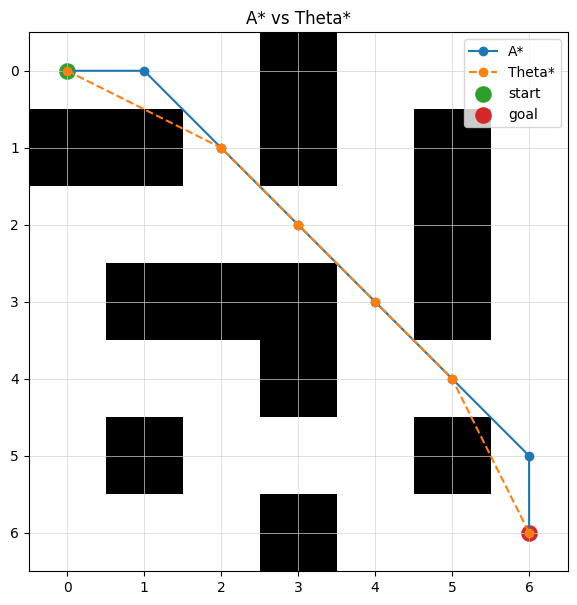

In [15]:
a_path = a_star_grid(grid, start, goal)
t_path = theta_star_grid(grid, start, goal)

print(f'A* path found: {a_path is not None}')
print(f'Theta* path found: {t_path is not None}')
print(f'A* path length: {path_length(a_path)}')
print(f'Theta* path length: {path_length(t_path)}')

draw_compare(grid, start, goal, a_path, t_path)

## 4) Explore Interactively

The widgets let you compare maps quickly and see when Theta* helps more than standard A*.

Try maps with long open regions: those are usually where Theta* looks best.

In [17]:
map_cases = {
    'Corridor': {
        'grid': np.array([
            [0, 0, 0, 1, 0, 0, 0],
            [1, 1, 0, 1, 0, 1, 0],
            [0, 0, 0, 0, 0, 1, 0],
            [0, 1, 1, 1, 0, 1, 0],
            [0, 0, 0, 1, 0, 0, 0],
            [0, 1, 0, 0, 0, 1, 0],
            [0, 0, 0, 1, 0, 0, 0],
        ], dtype=int),
        'start': (0, 0),
        'goal': (6, 6),
    },
    'Open Center': {
        'grid': np.array([
            [0, 0, 0, 0, 0, 0, 0],
            [0, 1, 1, 0, 1, 1, 0],
            [0, 1, 0, 0, 0, 1, 0],
            [0, 0, 0, 0, 0, 0, 0],
            [0, 1, 0, 0, 0, 1, 0],
            [0, 1, 1, 0, 1, 1, 0],
            [0, 0, 0, 0, 0, 0, 0],
        ], dtype=int),
        'start': (0, 0),
        'goal': (6, 6),
    },
    'Blocked': {
        'grid': np.array([
            [0, 0, 0, 1, 0, 0, 0],
            [1, 1, 0, 1, 0, 1, 0],
            [0, 0, 0, 1, 0, 1, 0],
            [0, 1, 1, 1, 0, 1, 0],
            [0, 0, 0, 1, 0, 0, 0],
            [0, 1, 0, 0, 0, 1, 1],
            [0, 0, 0, 1, 0, 1, 0],
        ], dtype=int),
        'start': (0, 0),
        'goal': (6, 6),
    },
}

map_selector = widgets.Dropdown(
    options=list(map_cases.keys()),
    value='Corridor',
    description='Map',
)

output = widgets.Output()

def update_view(*_args):
    case = map_cases[map_selector.value]
    grid_local = case['grid']
    start_local = case['start']
    goal_local = case['goal']

    with output:
        output.clear_output(wait=True)
        a_path_local = a_star_grid(grid_local, start_local, goal_local)
        t_path_local = theta_star_grid(grid_local, start_local, goal_local)
        print(f'A* path found: {a_path_local is not None}')
        print(f'Theta* path found: {t_path_local is not None}')
        print(f'A* path length: {path_length(a_path_local)}')
        print(f'Theta* path length: {path_length(t_path_local)}')
        draw_compare(grid_local, start_local, goal_local, a_path_local, t_path_local, title='A* vs Theta* interactive view')

map_selector.observe(update_view, names='value')
display(widgets.VBox([map_selector, output]))
update_view()